# 📊 Verteilungsanalyse: Elite Herren (Männer Hauptklasse)

**Ziel:** Analyse der Verteilung der IAAF Scores für die Altersklasse "Männer". 
Dies dient als Vorbereitung für statistische Tests (z.B. t-Tests, ANOVA, Regression), um zu prüfen, ob die Annahme der Normalverteilung verletzt ist.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
from plotting.plotting_style import rgb
import plotting.plotting_style as plt_style

# Load Data
df = util.load_data()

# Filter for Elite Men (Männer Hauptklasse)
# Assuming 'Männer' is the label in 'altersklasse' and 'M' in 'geschlecht'
df_men = df[(df['altersklasse'] == 'Maenner')].copy()

print(f"Datensätze für Elite Herren: {len(df_men)}")
df_men.head()

Datensätze für Elite Herren: 23216


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
4454,2005,M,Maenner,100 m,10.16,0.3,Tobias Unger,1979,LAZ Salamander Kornwesth./Lud.,02.07.,Wattenscheid,1152
4455,2005,M,Maenner,100 m,10.28,1.3,Alexander Kosenkow,1977,TV Wattenscheid 01,02.07.,Wattenscheid,1112
4456,2005,M,Maenner,100 m,10.29,0.3,Marc Blume,1973,TV Wattenscheid 01,02.07.,Wattenscheid,1108
4457,2005,M,Maenner,100 m,10.31,0.3,Marius Broening,1983,LAV asics Tuebingen,02.07.,Wattenscheid,1102
4458,2005,M,Maenner,100 m,10.37,0.8,Daniel Schnelting,1986,LAZ Rhede,29.07.,Braunschweig,1082


## 1. Histogramm & Dichtefunktion (KDE)
Hier sehen wir die generelle Form der Verteilung. Ist sie symmetrisch? Gibt es "Fat Tails"?

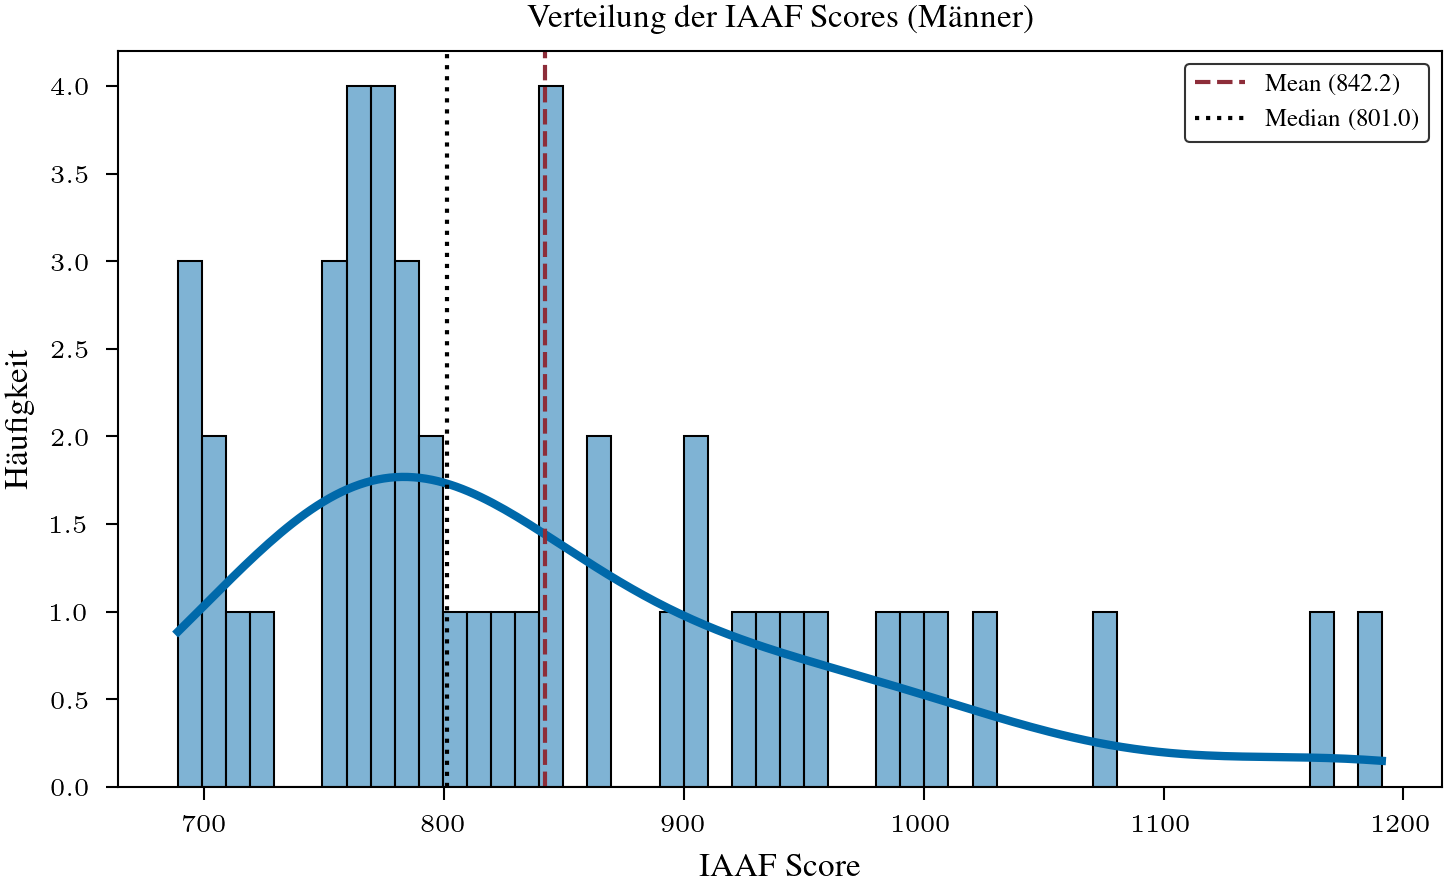

In [20]:
with plt.rc_context(plt_style.increase_figsize(1.5)):
    fig, ax = plt.subplots()

    df_men_2024_100m = df_men[(df_men['jahr'] == 2024) & (df_men['disziplin'] == 'Hammerwurf')]
    
    # Histogram with Kernel Density Estimate
    sns.histplot(df_men_2024_100m['iaaf_score'], kde=True, color=rgb.tue_blue, bins=50, ax=ax, line_kws={'linewidth': 2})
    
    # Add Mean and Median lines
    mean_val = df_men_2024_100m['iaaf_score'].mean()
    median_val = df_men_2024_100m['iaaf_score'].median()
    
    ax.axvline(mean_val, color=rgb.tue_red, linestyle='--', label=f'Mean ({mean_val:.1f})')
    ax.axvline(median_val, color='black', linestyle=':', label=f'Median ({median_val:.1f})')
    
    ax.set_title('Verteilung der IAAF Scores (Männer)')
    ax.set_xlabel('IAAF Score')
    ax.set_ylabel('Häufigkeit')
    ax.legend()
    
    plt.show()

## 2. Q-Q Plot (Quantile-Quantile)
Der Q-Q Plot vergleicht die Datenquantile mit den theoretischen Quantilen einer Normalverteilung. 
*   Liegen die Punkte auf der roten Linie, sind die Daten normalverteilt.
*   Abweichungen an den Enden deuten auf "Heavy Tails" (Ausreißer) hin.

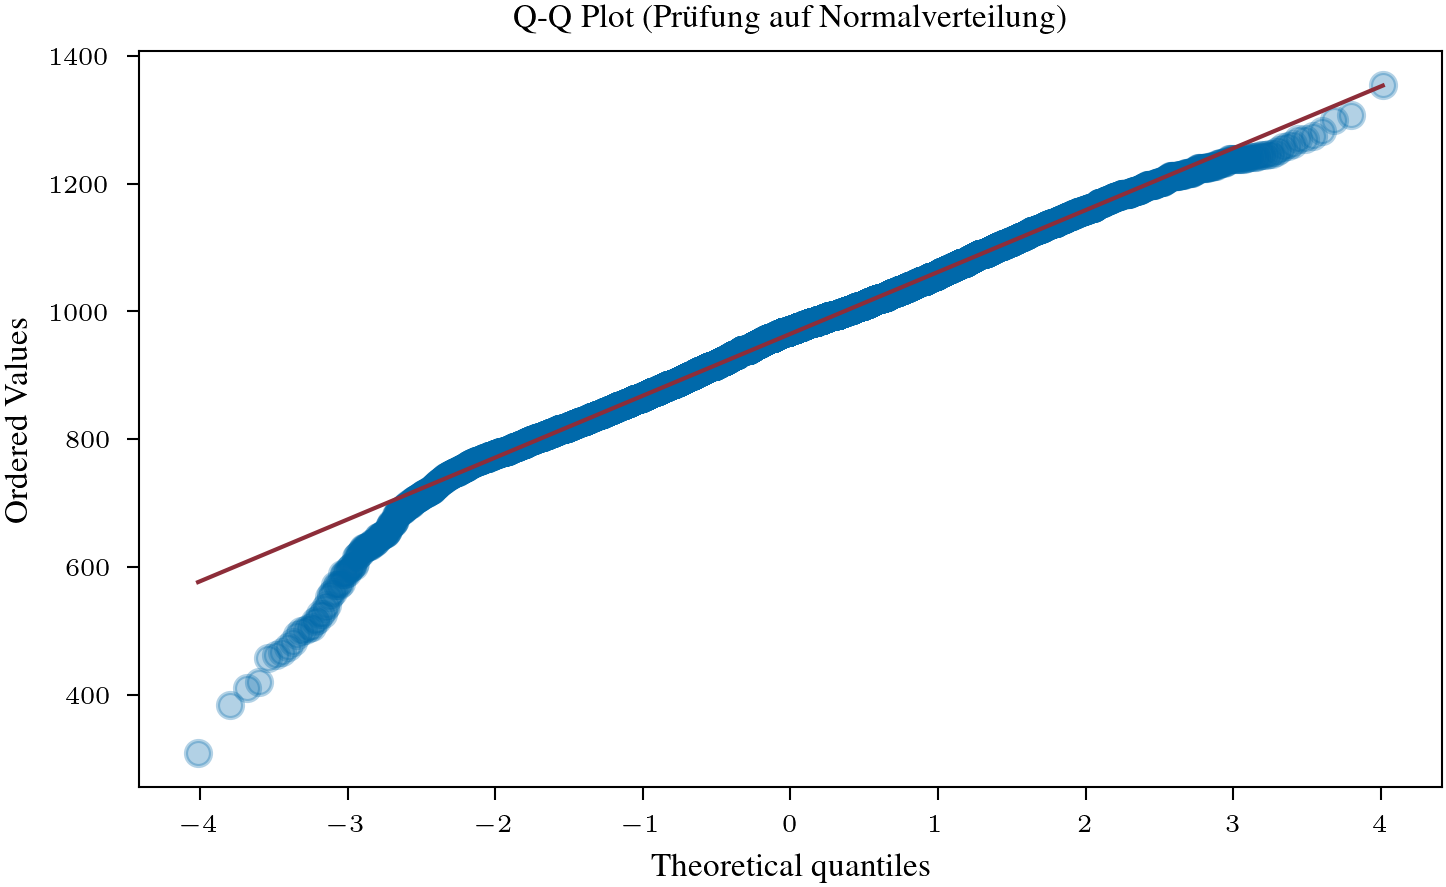

In [8]:
with plt.rc_context(plt_style.increase_figsize(1.5)):
    fig, ax = plt.subplots()
    
    # Generate Q-Q plot
    stats.probplot(df_men['iaaf_score'], dist="norm", plot=ax)
    
    ax.get_lines()[0].set_markerfacecolor(rgb.tue_blue)
    ax.get_lines()[0].set_markeredgecolor(rgb.tue_blue)
    ax.get_lines()[0].set_alpha(0.3)
    ax.get_lines()[1].set_color(rgb.tue_red) # The regression line
    
    ax.set_title('Q-Q Plot (Prüfung auf Normalverteilung)')
    plt.show()

## 3. Statistische Kennzahlen
Numerische Überprüfung der Verteilungseigenschaften.

In [12]:
desc_stats = df_men['iaaf_score'].describe()
skewness = df_men['iaaf_score'].skew()
kurtosis = df_men['iaaf_score'].kurtosis()

print("=== Deskriptive Statistik (IAAF Score - Männer) ===")
print(desc_stats)
print("=== Form der Verteilung ===")
print(f"Schiefe (Skewness): {skewness:.4f} (0 = symmetrisch, >0 = rechtsschief, <0 = linksschief)")
print(f"Wölbung (Kurtosis): {kurtosis:.4f} (0 = Normalverteilung [Fisher], >0 = steilgipflig, <0 = flachgipflig)")

if abs(skewness) > 0.5:
    print("HINWEIS: Die Daten weisen eine merkliche Schiefe auf. Parametrische Tests (z.B. t-Test) sind ggf. mit Vorsicht zu genießen oder erfordern Transformationen.")
else:
    print("HINWEIS: Die Daten sind annähernd symmetrisch.")

=== Deskriptive Statistik (IAAF Score - Männer) ===
count    23216.000000
mean       964.739145
std         97.054681
min        308.000000
25%        899.000000
50%        970.000000
75%       1026.000000
max       1355.000000
Name: iaaf_score, dtype: float64
=== Form der Verteilung ===
Schiefe (Skewness): -0.1696 (0 = symmetrisch, >0 = rechtsschief, <0 = linksschief)
Wölbung (Kurtosis): 0.5986 (0 = Normalverteilung [Fisher], >0 = steilgipflig, <0 = flachgipflig)
HINWEIS: Die Daten sind annähernd symmetrisch.


---
# 4. Deep Dive: 100m Sprint
Wir betrachten nun spezifisch die **100m** Disziplin. Da dies eine der populärsten Disziplinen mit hoher Leistungsdichte ist, ist die Verteilung hier besonders interessant.

In [ ]:
# Filter for 100m Men
df_100m = df_men[df_men['disziplin'] == '100 m'].copy()

print(f"Datensätze für 100m Männer: {len(df_100m)}")

with plt.rc_context(plt_style.increase_figsize(1.5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Histogram (IAAF Score)
    sns.histplot(df_100m['iaaf_score'], kde=True, color=rgb.tue_dark, bins=30, ax=ax1)
    ax1.set_title('Verteilung IAAF Score (100m)')
    ax1.set_xlabel('IAAF Score')
    
    # 2. Histogram (Raw Performance in seconds)
    # Note: Lower seconds = better, so the distribution is mirrored compared to points
    sns.histplot(df_100m['leistung'], kde=True, color=rgb.tue_red, bins=30, ax=ax2)
    ax2.invert_xaxis() # Faster times on the right to match logic of "better performance"
    ax2.set_title('Verteilung Laufzeit (100m in s)')
    ax2.set_xlabel('Sekunden (invertiert)')
    
    plt.show()

In [ ]:
# Q-Q Plot für 100m
with plt.rc_context(plt_style.increase_figsize(1.5)):
    fig, ax = plt.subplots()
    stats.probplot(df_100m['iaaf_score'], dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor(rgb.tue_dark)
    ax.get_lines()[0].set_markeredgecolor(rgb.tue_dark)
    ax.get_lines()[1].set_color(rgb.tue_red)
    ax.set_title('Q-Q Plot: 100m IAAF Scores')
    plt.show()

## 5. Exkurs: Warum sind Bestenlisten (oft nicht) normalverteilt?

Du hast vollkommen recht mit deiner Skepsis: **"Wir schauen uns ja nur die Top 30-50 an."**

Die theoretische Grundgesamtheit aller Menschen, die 100m laufen, wäre wahrscheinlich normalverteilt (die meisten sind durchschnittlich schnell, wenige extrem langsam, wenige extrem schnell).

Aber: **Eine Bestenliste ist ein "Truncated Sample" (abgeschnittene Stichprobe).**

### Das Phänomen des "Rechten Rands" (Tail Distribution)
1.  **Truncated Normal Distribution:** Wenn wir nur die Top 30 nehmen, schneiden wir den gesamten linken Teil und die Mitte der Glockenkurve weg. Wir betrachten nur den extremen rechten Rand. Ein Histogramm davon sieht oft aus wie eine **Rampe**, die nach rechts abfällt, oder (wenn die Selektion weicher ist) wie eine **schiefe Kurve**.
2.  **Extremwerttheorie (Extreme Value Theory - EVT):** Mathematisch folgen die Maxima aus Stichproben (was Bestleistungen ja sind) oft nicht der Normalverteilung, sondern einer **Gumbel-**, **Frechet-** oder **Weibull-Verteilung**.

### Warum sieht es hier trotzdem manchmal glockenförmig aus?
Es gibt zwei Effekte, die sich hier überlagern:
1.  **Feste Listenplätze (Top 30):** Da wir jedes Jahr eine feste Anzahl (z.B. Top 30) nehmen, ist der "Cut-off" (die Mindestleistung für Platz 30) variabel. In starken Jahren ist der Cut-off höher, in schwachen niedriger. Wenn wir *viele Jahre* mischen (wie in diesem Plot), verschwimmen die harten Kanten der einzelnen Jahre.
2.  **Interne Dichte:** Innerhalb der Elite gibt es wiederum einen "Durchschnitt der Elite". Die meisten Top-Athleten laufen um die 10.20s - 10.40s. Nur absolute Ausnahmetalente (wie Julian Reus oder Lucas Ansah-Peprah in Spitzenzeiten) laufen unter 10.10s. Das erzeugt wieder einen "Berg" in der Mitte der Elite-Verteilung, mit Ausläufern zu den "ganz Schnellen" und den "gerade so Qualifizierten".

### Fazit für die Statistik
Wenn der Q-Q Plot und das Histogramm zeigen, dass die Daten **linksschief** (bei Zeiten) oder **rechtsschief** (bei Punkten) sind, ist das typisch für Elite-Daten. Für t-Tests ist das bei großen Stichproben (n > 30) dank des **Zentralen Grenzwertsatzes** oft weniger problematisch als man denkt, aber nicht-parametrische Tests (wie **Mann-Whitney-U**) sind oft die sicherere Wahl, da sie keine Normalverteilung voraussetzen.

✦ Hier ist eine ausführliche Erklärung, die deine Fragen zur Standardabweichung, der Verteilung der IAAF-Scores und den richtigen statistischen
  Methoden beantwortet.

  ---

  1. Kann ich die Standardabweichung von nicht normalverteilten Daten berechnen?

  Ja, rein mathematisch kannst du das immer tun.
  Die Formel für die Standardabweichung (SD) funktioniert für jede Zahlenreihe, egal wie sie verteilt ist.

  Aber: Die Interpretation ändert sich drastisch.
   * Bei Normalverteilung: Gilt die Faustregel (68-95-99.7 Regel).
       * Mittelwert ± 1 SD deckt ca. 68% der Athleten ab.
       * Mittelwert ± 2 SD deckt ca. 95% ab.
   * Bei schiefen Verteilungen (wie oft im Sport): Gilt diese Regel nicht.
       * Wenn du z.B. einen "Superstar" (Ausreißer nach oben) hast, zieht dieser den Mittelwert nach oben und vergrößert die Standardabweichung enorm.
       * Beispiel: Eine Gruppe läuft 10.5s, 10.6s, 10.7s ... und einer läuft 9.58s. Die SD wird sehr groß, obwohl alle bis auf einen sehr eng
         beieinander liegen.

  Fazit: Du darfst sie berechnen und als "Maß für die Streuung" angeben, aber du solltest sie nicht benutzen, um Aussagen wie "95% der Athleten liegen
  in Bereich X" zu treffen. Dafür sind Quantile (siehe unten) besser.

  ---

  2. Sind die IAAF-Scores normalverteilt?

  Du hast zwei Faktoren angesprochen:
   1. Die Berechnung (Quadratisch/Kubisch): IAAF-Scores basieren meist auf Formeln wie $Punkte = a \cdot (M - b)^c$. Das sorgt dafür, dass
      Verbesserungen im extremen Spitzenbereich mehr Punkte bringen als im mittleren Bereich. Das streckt die Verteilung am oberen Ende ("Right Tail").
      Das fördert eher eine Schiefe als eine Normalverteilung.
   2. Der Cut-off (Top 30/50): Du schneidest den gesamten unteren Bereich ab.

  Die Antwort:
  Nein, deine Daten sind höchstwahrscheinlich nicht perfekt normalverteilt.
  Sie sind eine abgeschnittene (truncated) Verteilung, die oft rechts-schief (right-skewed) ist.

   * Links (unten): Eine harte Wand (der Cut-off für Platz 50/30). Niemand ist schlechter als das, sonst wären sie nicht im Datensatz.
   * Rechts (oben): Ein langer Ausläufer. Es gibt keine harte Obergrenze für Leistung. Ein einzelner Rekordhalter kann sich weit vom Feld absetzen
     (hoher Score).

  Warum sehen sie im Plot manchmal trotzdem wie eine Glocke aus?
  Wie im Notebook erklärt: Wenn du viele Jahre mischst, verschwimmt die harte Kante unten (weil der Cut-off jedes Jahr woanders liegt). Das erzeugt
  künstlich eine "linke Flanke" der Glocke. Aber für ein einzelnes Jahr ist die Verteilung oft eher ein "halber Hügel".

  ---

  3. Welche Metriken und Tests sind "am robustesten und richtigsten"?

  Da wir uns bei Elite-Sportlern im Bereich der Extremwerte bewegen und die Normalverteilung wackelig ist, solltest du robuste (nicht-parametrische)
  Methoden bevorzugen. Damit bist du auf der sicheren Seite und vermeidest Angriffsfläche bei der Interpretation.

  A. Deskriptive Statistik (Zum Beschreiben)


  ┌─────────────┬───────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────
  ──┐
  │ Statt ..... │ ... Benutze lieber das... │ Warum?
  │
  ├─────────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────
  ──┤
  │ **Mittel... │ Median                    │ Der Median ist der Wert genau in der Mitte. Wenn ein Usain Bolt plötzlich 100 Punkte mehr hat, zieht
  er... │
  │ **Standa... │ IQR (Interquartile Range) │ Der IQR ist der Abstand zwischen dem 25. und 75. Perzentil (die mittleren 50% der Athleten). Er
  ignorie... │
  │ Min / Max   │ **Perzentile (z.B. 10%... │ Min und Max hängen oft von Zufällen oder einzelnen Personen ab. Das 90. Perzentil ist ein stabilerer
  In... │
  └─────────────┴───────────────────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────
  ──┘


  B. Statistische Tests (Zum Vergleichen, z.B. "War 2020 schlechter als 2019?")

  Hier ist die wichtigste Unterscheidung.

  1. Der "Gold Standard" für deine Daten: Mann-Whitney U Test (auch Wilcoxon Rank-Sum Test)
   * Was er macht: Er vergleicht nicht die Durchschnittswerte, sondern die Ränge. Er sortiert alle Athleten aus 2019 und 2020 in eine Liste und schaut,
     ob die Athleten aus 2019 tendenziell auf den vorderen Plätzen stehen.
   * Vorteil: Er benötigt keine Normalverteilung. Er funktioniert auch mit abgeschnittenen Daten perfekt. Er ist extrem robust gegen Ausreißer.
   * Interpretation: "Die Verteilung der Leistungen in 2020 unterscheidet sich signifikant von 2019." (Er testet auf stochastische Dominanz).

  2. Der t-Test (Student's t-test)
   * Was er macht: Vergleicht Mittelwerte und Standardabweichungen.
   * Problem: Setzt Normalverteilung voraus.
   * Aber: Bei großen Stichproben (N > 30, was du meistens hast) greift der Zentrale Grenzwertsatz. Das bedeutet, der t-Test ist oft trotzdem gültig
     ("robust"), auch wenn die Daten schief sind.
   * Empfehlung: Du kannst ihn benutzen, aber der Mann-Whitney U Test ist "sauberer" für diese Art von Daten.

  3. Effektstärke (Wie groß ist der Unterschied?)
   * Statt Cohen's d (basiert auf Mittelwert/SD), benutze lieber Cliff's Delta oder Rank-Biserial Correlation. Diese sagen dir: "Wie wahrscheinlich ist
     es, dass ein zufälliger Athlet aus 2019 besser ist als einer aus 2020?"

  ---

  4. Was solltest du vermeiden (Red Flags)?

   1. Aussagen über die "Durchschnittsleistung" basierend auf dem arithmetischen Mittel:
       * Schreibe nicht: "Der durchschnittliche Top-Athlet hatte 1100 Punkte", wenn der Mittelwert durch zwei Superstars verzerrt ist. Schreibe lieber:
         "Der Median lag bei 1080 Punkten."

   2. Annahme, dass fehlende Daten = 0 sind:
       * In 2020 fehlen vielleicht viele Athleten in der Liste (weniger Wettkämpfe). Wenn du die Listenlänge vergleichst (N=50 vs N=30), ist das ein
         Ergebnis an sich. Fülle die fehlenden 20 Plätze nicht mit Nullen oder dem Mittelwert auf, das verfälscht alles.

   3. Vorsicht bei kleinen Subgruppen:
       * Wenn du z.B. "Männer U18 Diskuswurf" anschaust und nur 10 Datenpunkte hast: Auf keinen Fall t-Tests nutzen! Hier ist die Normalverteilung fast
         sicher verletzt und N ist zu klein für den Grenzwertsatz. Hier muss der Mann-Whitney U Test (oder Exakter Test nach Fisher bei Häufigkeiten)
         ran.

  Zusammenfassung für deinen Report

   1. Benutze Boxplots (die zeigen Median und IQR automatisch), um Jahre zu vergleichen.
   2. Benutze den Median für Trendlinien im Zeitverlauf.
   3. Benutze den Mann-Whitney U Test, um zu prüfen, ob der Einbruch 2020 "signifikant" ist.
   4. Argumentiere damit, dass dies konservativer und robuster ist als Mittelwertsvergleiche, da Sportdaten oft Extremwert-verteilt sind.